In [1]:
import pyspark
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml import Pipeline

# 1. Initialize Spark for Machine Learning
spark = SparkSession.builder.appName("Assignment1_ML").master("local[*]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

# 2. Load the Validated Gold Data
gold_path = "datamart/gold/feature_store/gold_feature_store_2024_08_01_90dpd_3mob.parquet"
df = spark.read.parquet(gold_path)

# 3. Drop unwanted columns (IDs, Metadata, and Highly Correlated features)
# We drop 'balance' because the audit showed it heavily correlates with 'paid_amt'
cols_to_drop = ["Customer_ID", "loan_id", "label_def", "balance"]
df = df.drop(*cols_to_drop)

# 4. Route features by data type
categorical_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, pyspark.sql.types.StringType)]
numeric_cols = [f.name for f in df.schema.fields if isinstance(f.dataType, (pyspark.sql.types.DoubleType, pyspark.sql.types.IntegerType))]
numeric_cols.remove("label") # Keep the target separate

# 5. Build the Preprocessing Stages
stages = []

# Loop through strings: Convert word -> number index -> binary vector
for cat_col in categorical_cols:
    indexer = StringIndexer(inputCol=cat_col, outputCol=cat_col+"_index", handleInvalid="keep")
    encoder = OneHotEncoder(inputCols=[indexer.getOutputCol()], outputCols=[cat_col+"_vec"])
    stages += [indexer, encoder]

# Assemble everything into a single "features" math vector
assembler_inputs = [c + "_vec" for c in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features", handleInvalid="skip")
stages += [assembler]

# 6. Execute the Pipeline
print("Executing Preprocessing Pipeline...")
pre_process_pipeline = Pipeline(stages=stages)
pre_process_model = pre_process_pipeline.fit(df)
df_ml = pre_process_model.transform(df)

# Output the final ML-ready matrix
print(f"Dataset ready: {df_ml.count()} rows.")
df_ml.select("features", "label").show(5, truncate=False)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/17 10:38:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Executing Preprocessing Pipeline...


Dataset ready: 460 rows.
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|features                                                                                                                                                                                                                                                    |label|
+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----+
|[1.0,1.0,1.0,1.0,1.0,1.0,10.0,3.0,10000.0,1000.0,3.0,0.0,104.0,314.0,-31.0,84.0,107.0,89.0,120.0,-31.0,17.0,107.0,-136.0,140.0,94.0,27.0,181.0,176.0,192.0,166.0,28.0,199.0,0.0,0.0,0.0,0.0,0.0

In [3]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import pyspark.sql.functions as F
from pyspark.sql.functions import col  # <-- Added missing import

print("=== STEP 2: CLASS WEIGHTING & DATA SPLIT ===")

# 1. Calculate weights to handle the 99% to 1% imbalance
pos_count = df_ml.filter(col("label") == 1).count()
neg_count = df_ml.filter(col("label") == 0).count()
total_rows = df_ml.count()

# Formula: Total / (2 * Class_Count). This makes the rare defaults heavily weighted.
weight_pos = total_rows / (2.0 * pos_count)
weight_neg = total_rows / (2.0 * neg_count)

print(f"Weight assigned to Defaults (1): {weight_pos:.2f}")
print(f"Weight assigned to Performing (0): {weight_neg:.2f}")

# 2. Append the exact weight to every row
df_ml = df_ml.withColumn("class_weight", F.when(col("label") == 1, weight_pos).otherwise(weight_neg))

# 3. Train / Test Split (80% training, 20% unseen testing)
train_data, test_data = df_ml.randomSplit([0.8, 0.2], seed=42)
print(f"\nTraining set: {train_data.count()} rows")
print(f"Testing set: {test_data.count()} rows")


print("\n=== STEP 3: RANDOM FOREST TRAINING & EVALUATION ===")

# 4. Initialize the Model (Notice we pass the weightCol here)
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="label", 
    weightCol="class_weight", 
    numTrees=100, 
    maxDepth=5, 
    seed=42
)

# 5. Train the Model
print("Training the Random Forest Classifier...")
rf_model = rf.fit(train_data)

# 6. Generate Predictions on the unseen Test Data
predictions = rf_model.transform(test_data)

# 7. Evaluate using ROC-AUC (Area Under the Receiver Operating Characteristic Curve)
# ROC-AUC is the gold standard for imbalanced credit risk models, not standard accuracy.
evaluator = BinaryClassificationEvaluator(
    labelCol="label", 
    rawPredictionCol="rawPrediction", 
    metricName="areaUnderROC"
)

auc_score = evaluator.evaluate(predictions)
print(f"\n✅ FINAL ROC-AUC SCORE: {auc_score:.4f}")

# Display a sample of what the model actually predicted vs reality
print("\nPrediction Sample (Probability Vector & Final Prediction):")
predictions.select("label", "probability", "prediction").show(10, truncate=False)

=== STEP 2: CLASS WEIGHTING & DATA SPLIT ===
Weight assigned to Defaults (1): 46.00
Weight assigned to Performing (0): 0.51



Training set: 394 rows
Testing set: 66 rows

=== STEP 3: RANDOM FOREST TRAINING & EVALUATION ===
Training the Random Forest Classifier...



✅ FINAL ROC-AUC SCORE: 0.9385

Prediction Sample (Probability Vector & Final Prediction):
+-----+-----------------------------------------+----------+
|label|probability                              |prediction|
+-----+-----------------------------------------+----------+
|0    |[0.9405060961104431,0.059493903889556915]|0.0       |
|0    |[0.9603363120531945,0.03966368794680553] |0.0       |
|0    |[0.8617090907841768,0.13829090921582315] |0.0       |
|0    |[0.8734591700521419,0.12654082994785817] |0.0       |
|0    |[0.950469379592581,0.04953062040741898]  |0.0       |
|0    |[0.8612598926939079,0.13874010730609215] |0.0       |
|0    |[0.9511962312377412,0.048803768762258885]|0.0       |
|0    |[0.9702008106981809,0.029799189301819077]|0.0       |
|1    |[0.9142596680682106,0.08574033193178947] |0.0       |
|0    |[0.9706419871687691,0.029358012831230847]|0.0       |
+-----+-----------------------------------------+----------+
only showing top 10 rows



=== STEP 4: MODEL EXPLAINABILITY (FINAL) ===

Top 10 Most Important Variables:
 Feature  Importance
paid_amt    0.143003
   fe_11    0.117646
    fe_1    0.079460
   fe_13    0.074923
   fe_16    0.070699
   fe_15    0.048847
   fe_19    0.046025
    fe_7    0.042970
    fe_5    0.041383
    fe_9    0.039485


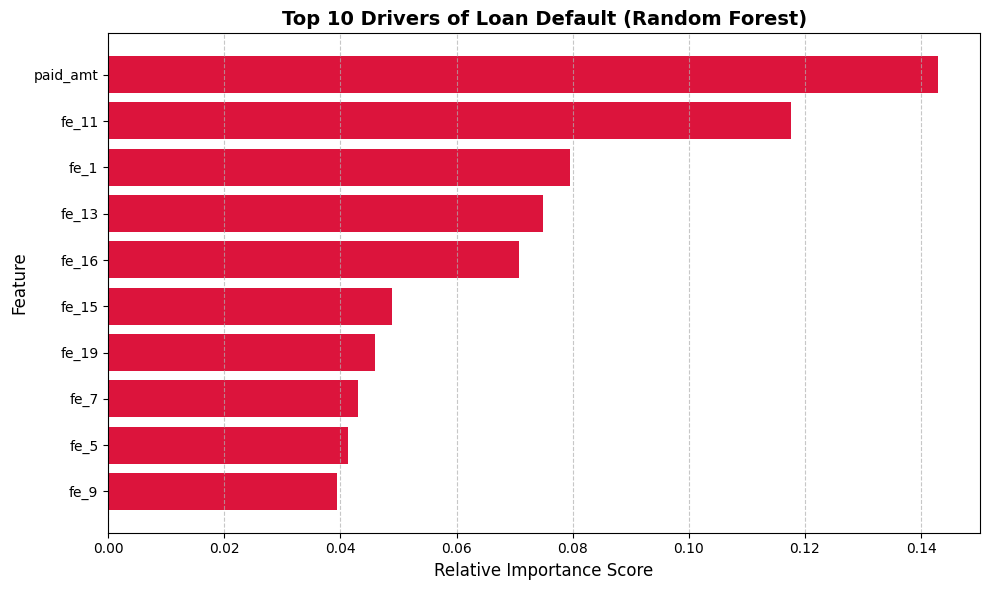

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

print("=== STEP 4: MODEL EXPLAINABILITY (FINAL) ===")

# 1. Extract the raw mathematical importance scores from the Random Forest
importances = rf_model.featureImportances.toArray()

# 2. Map them directly back to the exact inputs from Step 1
feature_names = assembler_inputs

# 3. Combine them into a clean Pandas DataFrame and sort them
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Most Important Variables:")
print(importance_df.head(10).to_string(index=False))

# 4. Plot the results for your presentation/report
plt.figure(figsize=(10, 6))
# Reverse the order so the biggest bar shows at the top
plt.barh(importance_df["Feature"][:10][::-1], importance_df["Importance"][:10][::-1], color='crimson')
plt.title("Top 10 Drivers of Loan Default (Random Forest)", fontsize=14, fontweight='bold')
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()